## 1. Load Pipeline and Data

Load the saved Random Forest pipeline and raw features.

In [14]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

pipeline = joblib.load('../models/attrition_pipeline.joblib')
X = pd.read_csv('../data/features/X_features.csv')
y = pd.read_csv('../data/features/y_target.csv').iloc[:, 0].map({'No': 0, 'Yes': 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (400, 25), Test: (100, 25)


## 2. Extract Preprocessor and Model

Pipeline steps are named 'columntransformer' and 'randomforestclassifier'.

In [15]:
preprocessor = pipeline.named_steps['columntransformer']
model = pipeline.named_steps['randomforestclassifier']

print(f'Preprocessor: {type(preprocessor).__name__}')
print(f'Model: {type(model).__name__}')

Preprocessor: ColumnTransformer
Model: RandomForestClassifier


## 3. Transform X_test

SHAP needs the numeric (transformed) data.

In [16]:
X_test_transformed = preprocessor.transform(X_test)

if hasattr(preprocessor, 'get_feature_names_out'):
    feature_names = preprocessor.get_feature_names_out()
else:
    feature_names = X.columns

print(f'Transformed shape: {X_test_transformed.shape}')
print(f'Feature names: {len(feature_names)}')

Transformed shape: (100, 68)
Feature names: 68


## 4. Run SHAP

In [17]:
explainer = shap.TreeExplainer(model)
shap_values_raw = explainer.shap_values(X_test_transformed)

print(f'Raw SHAP type: {type(shap_values_raw)}')
if isinstance(shap_values_raw, list):
    shap_values = shap_values_raw[1]
    expected_value = explainer.expected_value[1]
elif hasattr(shap_values_raw, 'ndim') and shap_values_raw.ndim == 3:
    shap_values = shap_values_raw[:, :, 1]
    expected_value = explainer.expected_value[1] if hasattr(explainer.expected_value, '__len__') else explainer.expected_value
else:
    shap_values = shap_values_raw
    expected_value = explainer.expected_value

if hasattr(expected_value, '__len__'):
    expected_value = float(expected_value[1]) if len(expected_value) > 1 else float(expected_value[0])
else:
    expected_value = float(expected_value)

print(f'SHAP values shape: {shap_values.shape}')
print(f'Expected value: {expected_value:.4f}')

Raw SHAP type: <class 'numpy.ndarray'>
SHAP values shape: (100, 68)
Expected value: 0.5052


## 5. Global Explanation - What Drives Attrition?

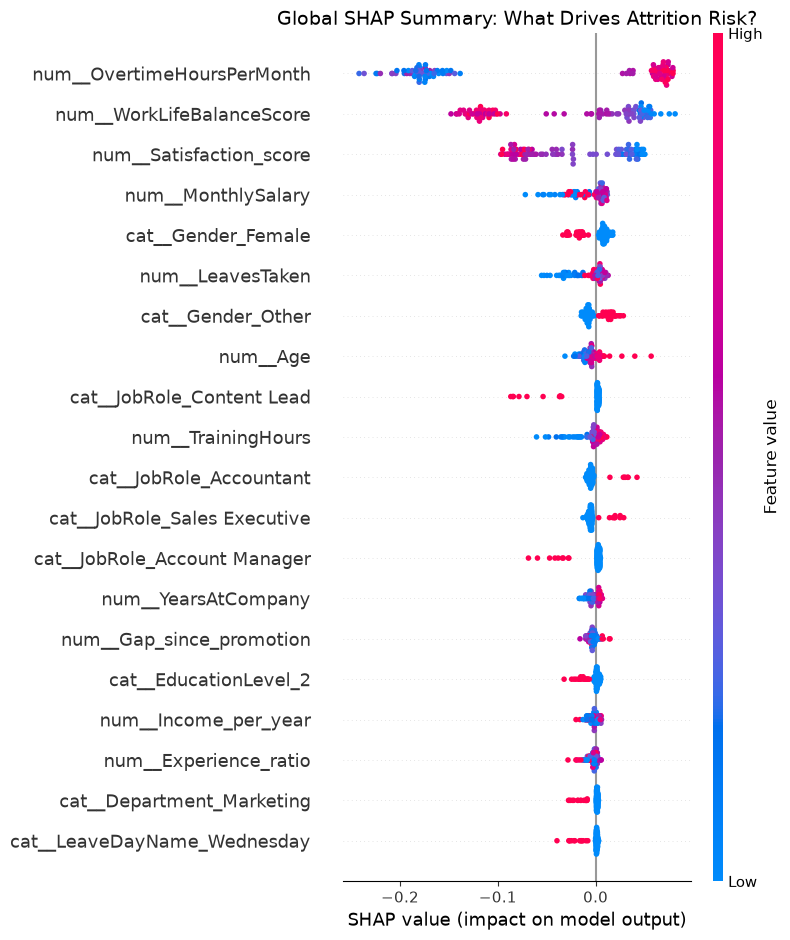

Saved: ../docs/shap_summary.png


In [18]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, show=False)
plt.title('Global SHAP Summary: What Drives Attrition Risk?', fontsize=14)
plt.tight_layout()
plt.savefig('../docs/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../docs/shap_summary.png')

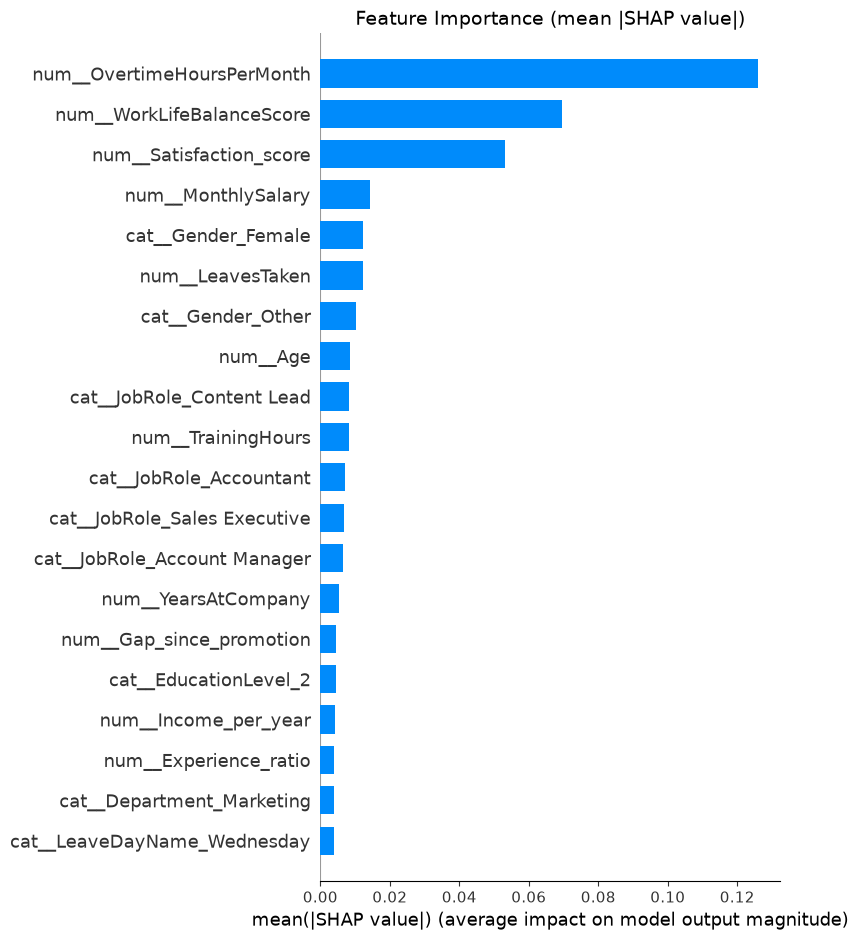

Saved: ../docs/shap_bar.png


In [19]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, plot_type='bar', show=False)
plt.title('Feature Importance (mean |SHAP value|)', fontsize=14)
plt.tight_layout()
plt.savefig('../docs/shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../docs/shap_bar.png')

## 6. Local Explanation - Why This Employee?

In [20]:
y_prob = pipeline.predict_proba(X_test)[:, 1]
highest_risk_idx = np.argmax(y_prob)

print(f'Highest risk employee: test index {highest_risk_idx}')
print(f'Attrition probability: {y_prob[highest_risk_idx]:.2%}')
print(f'Actual: {"Yes" if y_test.iloc[highest_risk_idx] == 1 else "No"}')

Highest risk employee: test index 9
Attrition probability: 71.70%
Actual: Yes


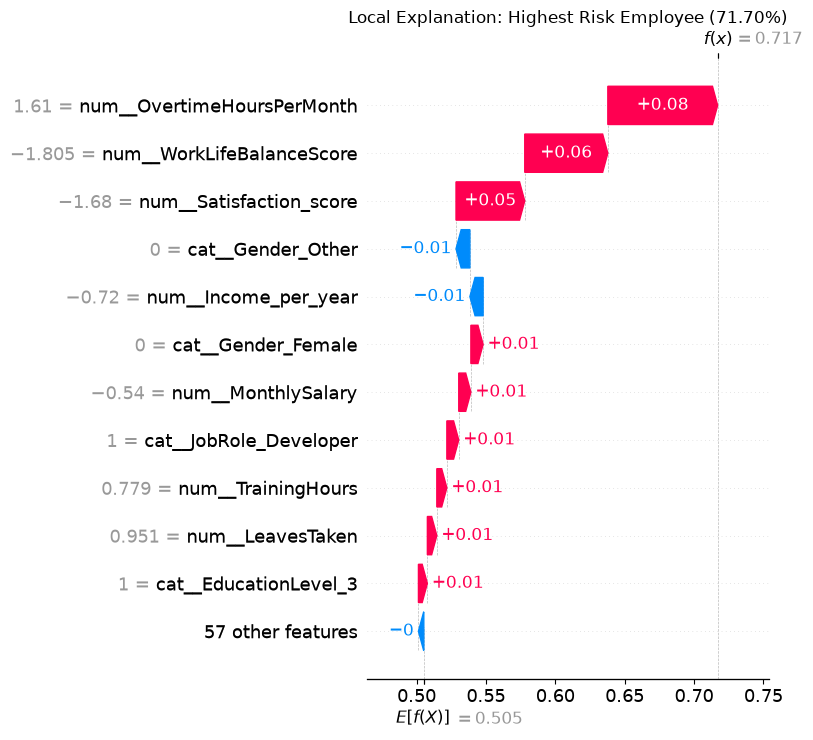

Saved: ../docs/shap_waterfall_top.png


In [21]:
explanation = shap.Explanation(
    values=shap_values[highest_risk_idx],
    base_values=expected_value,
    data=X_test_transformed[highest_risk_idx],
    feature_names=feature_names
)

plt.figure(figsize=(10, 8))
shap.plots.waterfall(explanation, max_display=12, show=False)
plt.title(f'Local Explanation: Highest Risk Employee ({y_prob[highest_risk_idx]:.2%})', fontsize=12)
plt.tight_layout()
plt.savefig('../docs/shap_waterfall_top.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../docs/shap_waterfall_top.png')

True Positive: test index 9
Attrition probability: 71.70%


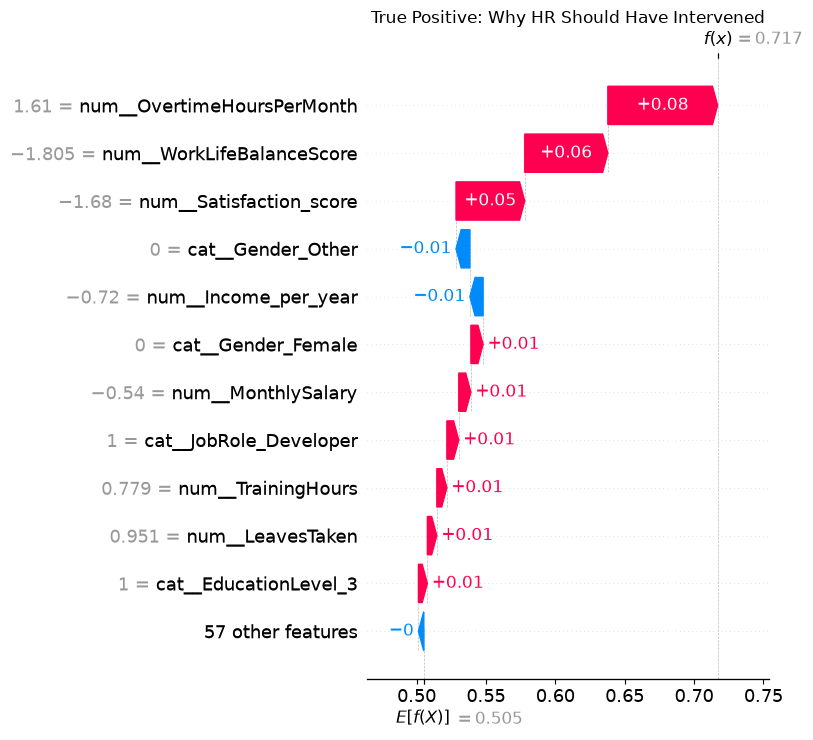

Saved: ../docs/shap_waterfall_true_positive.png


In [22]:
y_pred = pipeline.predict(X_test)
true_positives = np.where((y_test.values == 1) & (y_pred == 1))[0]

if len(true_positives) > 0:
    tp_idx = true_positives[0]
    print(f'True Positive: test index {tp_idx}')
    print(f'Attrition probability: {y_prob[tp_idx]:.2%}')

    tp_explanation = shap.Explanation(
        values=shap_values[tp_idx],
        base_values=expected_value,
        data=X_test_transformed[tp_idx],
        feature_names=feature_names
    )

    plt.figure(figsize=(10, 8))
    shap.plots.waterfall(tp_explanation, max_display=12, show=False)
    plt.title('True Positive: Why HR Should Have Intervened', fontsize=12)
    plt.tight_layout()
    plt.savefig('../docs/shap_waterfall_true_positive.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: ../docs/shap_waterfall_true_positive.png')
else:
    print('No true positives found.')

## 7. Dependence Plot

Shows how the top feature affects predictions.

<Figure size 1000x600 with 0 Axes>

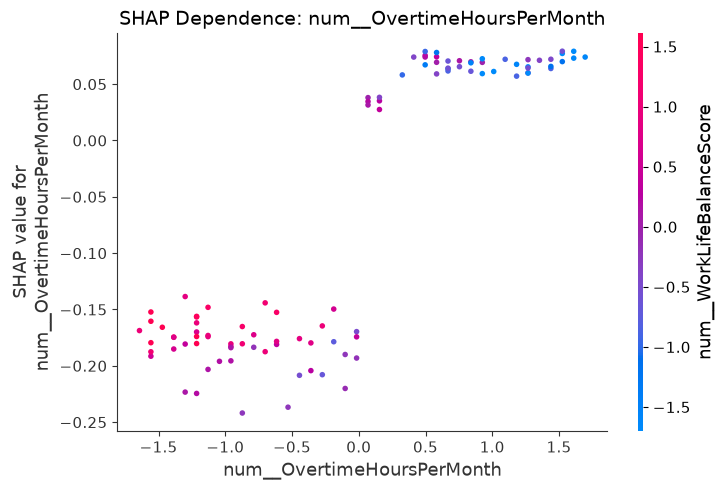

Saved: ../docs/shap_dependence.png


In [23]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_feature_idx = np.argsort(mean_abs_shap)[-1]

plt.figure(figsize=(10, 6))
shap.dependence_plot(
    top_feature_idx, shap_values, X_test_transformed,
    feature_names=feature_names, show=False
)
plt.title(f'SHAP Dependence: {feature_names[top_feature_idx]}', fontsize=14)
plt.tight_layout()
plt.savefig('../docs/shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../docs/shap_dependence.png')

## Summary

### Global - What Drives Attrition?
The SHAP plots identify top features pushing employees toward attrition.

### Local - Why This Employee?
The waterfall plot shows the personal top factors for the highest-risk employee.

### Plots Saved to `docs/`
- `shap_summary.png` - Global feature impact
- `shap_bar.png` - Feature importance ranking
- `shap_waterfall_top.png` - Why highest-risk employee is flagged
- `shap_waterfall_true_positive.png` - Why a real leaver was caught
- `shap_dependence.png` - Feature interaction effect